## Team Member Names & Contributions

- **Arushi Munjal, A174611994**: 
- **Jaidy Leyva, A17536634**: 
- **Shafana Shahul**: 

In [61]:
import sys
print(sys.executable)  # should show myenv path

import nibabel as nib
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import abagen
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from scipy import stats
import zipfile
import os

print("All working!")

c:\Users\user\myenv\Scripts\python.exe
All working!


#### Allen Dataset

In [3]:
pip install allensdk

Note: you may need to restart the kernel to use updated packages.


In [102]:
# Import the "Cell Types Cache" from the AllenSDK core package
from allensdk.core.cell_types_cache import CellTypesCache

# Import CellTypesApi in order to query the database.
from allensdk.api.queries.cell_types_api import CellTypesApi

# Initialize the cache as 'ctc' (cell types cache)
ctc = CellTypesCache(manifest_file=r'C:\Users\user\Downloads\abagen_data\cell_types_manifest.json')

#### HCP Dataset Wrangling

In [86]:
zip_path = r'C:\Users\user\Downloads\The+WU-Minn+Human+Connectome+Project_+An+overview.zip'
extract_path = r'C:\Users\user\Downloads\hcp_gambling'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted Files:")
for f in os.listdir(extract_path):
    print(f)

subfolder = r'C:\Users\user\Downloads\hcp_gambling\The WU-Minn Human Connectome Project_ An overview'
for f in os.listdir(subfolder):
    print(repr(f))

Extracted Files:
The WU-Minn Human Connectome Project_ An overview
'tfMRI_EMOTION_FACES-SHAPES_zstat1.nii.gz'
'tfMRI_EMOTION_FACES_zstat1.nii.gz'
'tfMRI_EMOTION_SHAPES_zstat1.nii.gz'
'tfMRI_GAMBLING_PUNISH_zstat1.nii.gz'
'tfMRI_GAMBLING_REWARD-PUNISH_zstat1.nii.gz'
'tfMRI_GAMBLING_REWARD_zstat1.nii.gz'
'tfMRI_LANGUAGE_MATH_zstat1.nii.gz'
'tfMRI_LANGUAGE_STORY-MATH_zstat1.nii.gz'
'tfMRI_LANGUAGE_STORY_zstat1.nii.gz'
'tfMRI_MOTOR_AVG_zstat1.nii.gz'
'tfMRI_MOTOR_CUE-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_CUE_zstat1.nii.gz'
'tfMRI_MOTOR_LF-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_LF_zstat1.nii.gz'
'tfMRI_MOTOR_LH-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_LH_zstat1.nii.gz'
'tfMRI_MOTOR_RF-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_RF_zstat1.nii.gz'
'tfMRI_MOTOR_RH-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_RH_zstat1.nii.gz'
'tfMRI_MOTOR_T-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_T_zstat1.nii.gz'
'tfMRI_RELATIONAL_MATCH-REL_zstat1.nii.gz'
'tfMRI_RELATIONAL_MATCH_zstat1.nii.gz'
'tfMRI_RELATIONAL_REL-MATCH.nii_tstat1.nii.gz'
'tfMRI_RELATIONAL_REL_zs

In [87]:
base = r'C:\Users\user\Downloads\hcp_gambling\The WU-Minn Human Connectome Project_ An overview'
for f in os.listdir(base):
    print(repr(f))

'tfMRI_EMOTION_FACES-SHAPES_zstat1.nii.gz'
'tfMRI_EMOTION_FACES_zstat1.nii.gz'
'tfMRI_EMOTION_SHAPES_zstat1.nii.gz'
'tfMRI_GAMBLING_PUNISH_zstat1.nii.gz'
'tfMRI_GAMBLING_REWARD-PUNISH_zstat1.nii.gz'
'tfMRI_GAMBLING_REWARD_zstat1.nii.gz'
'tfMRI_LANGUAGE_MATH_zstat1.nii.gz'
'tfMRI_LANGUAGE_STORY-MATH_zstat1.nii.gz'
'tfMRI_LANGUAGE_STORY_zstat1.nii.gz'
'tfMRI_MOTOR_AVG_zstat1.nii.gz'
'tfMRI_MOTOR_CUE-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_CUE_zstat1.nii.gz'
'tfMRI_MOTOR_LF-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_LF_zstat1.nii.gz'
'tfMRI_MOTOR_LH-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_LH_zstat1.nii.gz'
'tfMRI_MOTOR_RF-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_RF_zstat1.nii.gz'
'tfMRI_MOTOR_RH-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_RH_zstat1.nii.gz'
'tfMRI_MOTOR_T-AVG_zstat1.nii.gz'
'tfMRI_MOTOR_T_zstat1.nii.gz'
'tfMRI_RELATIONAL_MATCH-REL_zstat1.nii.gz'
'tfMRI_RELATIONAL_MATCH_zstat1.nii.gz'
'tfMRI_RELATIONAL_REL-MATCH.nii_tstat1.nii.gz'
'tfMRI_RELATIONAL_REL_zstat1.nii.gz'
'tfMRI_SOCIAL_RANDOM_zstat1.nii.gz'
'tfMRI_SOCIAL_TOM-

In [88]:
reward_punish = nib.load(os.path.join(base, 'tfMRI_GAMBLING_REWARD-PUNISH_zstat1.nii.gz'))
reward        = nib.load(os.path.join(base, 'tfMRI_GAMBLING_REWARD_zstat1.nii.gz'))
punish        = nib.load(os.path.join(base, 'tfMRI_GAMBLING_PUNISH_zstat1.nii.gz'))

print("reward_punish:", reward_punish.shape)
print("reward:",        reward.shape)
print("punish:",        punish.shape)
print("All loaded successfully!")

reward_punish: (91, 109, 91)
reward: (91, 109, 91)
punish: (91, 109, 91)
All loaded successfully!


Peak activation at voxel: (39, 17, 45)


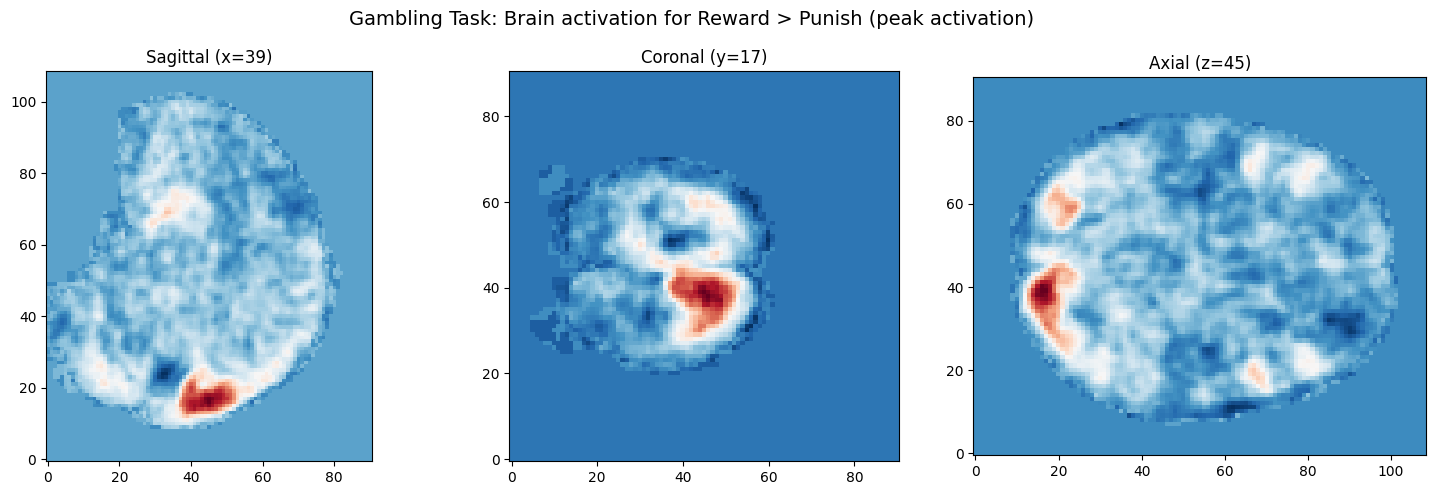

In [89]:
data = reward_punish.get_fdata()
peak = np.unravel_index(np.argmax(data), data.shape)
print("Peak activation at voxel:", peak)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(data[peak[0], :, :], cmap='RdBu_r', origin='lower')
axes[0].set_title(f'Sagittal (x={peak[0]})')
axes[1].imshow(data[:, peak[1], :], cmap='RdBu_r', origin='lower')
axes[1].set_title(f'Coronal (y={peak[1]})')
axes[2].imshow(data[:, :, peak[2]], cmap='RdBu_r', origin='lower')
axes[2].set_title(f'Axial (z={peak[2]})')

plt.suptitle('Gambling Task: Brain activation for Reward > Punish (peak activation)', fontsize=14)
plt.tight_layout()
plt.show()

#Red = stronger activation during reward > punishment (positive Z-stat)
#Blue = stronger activation during punishment > reward (negative Z-stat)
#White = little difference between conditions

Here we see a red cluster in the coronal view is the striatum/caudate — the primary reward processing region (fits expected for reward > punish). The axial view shows bilateral activation which is also expected.

In [90]:
voxel_coords = np.array([39, 17, 45, 1]) #confirms exact brain region
mni_coords = reward_punish.affine @ voxel_coords
print(f"Peak activation in MNI space: x={mni_coords[0]:.1f}, y={mni_coords[1]:.1f}, z={mni_coords[2]:.1f}")

Peak activation in MNI space: x=12.0, y=-92.0, z=18.0


In [91]:
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, resolution_mm=2)
atlas_img    = atlas.maps
atlas_labels = atlas.labels
print("Parcels:", len(atlas_labels))

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\user\nilearn_data\schaefer_2018
Parcels: 101


In [92]:
masker = NiftiLabelsMasker(labels_img=atlas_img, standardize=False) #parcellate the fMRI data
masker.fit()

rp_activation = masker.transform(reward_punish).flatten()
r_activation  = masker.transform(reward).flatten()
p_activation  = masker.transform(punish).flatten()

print("Number of parcels:", len(rp_activation))

Number of parcels: 100


In [93]:
labels = [l.decode() if isinstance(l, bytes) else l for l in atlas_labels] # decode bytes to strings if necessary and create clean dataframe
labels = labels[1:]  # remove background label so it matches the 100 lenght

activation_df = pd.DataFrame({
    'parcel_label':  labels,
    'reward_punish': rp_activation,
    'reward':        r_activation,
    'punish':        p_activation
})

print(activation_df.shape)
print(activation_df.head(10))

(100, 4)
            parcel_label  reward_punish     reward     punish
0     7Networks_LH_Vis_1       2.193728  -2.365583  -4.383722
1     7Networks_LH_Vis_2       5.432561  21.081312  19.977684
2     7Networks_LH_Vis_3       2.293952  12.808895  11.621621
3     7Networks_LH_Vis_4       3.306230   9.834748   8.662894
4     7Networks_LH_Vis_5       5.797865  21.320940  20.318979
5     7Networks_LH_Vis_6       3.396118  14.053095  12.721108
6     7Networks_LH_Vis_7       4.504007   9.674089   7.896776
7     7Networks_LH_Vis_8       5.718954  15.587968  14.110069
8     7Networks_LH_Vis_9       4.312005   6.541833   4.565026
9  7Networks_LH_SomMot_1      -1.403067  -7.825548  -6.715819


In [94]:
pfc_keywords = ['Frontal', 'Cingulate', 'Orbital', 'ACC', 'PFC'] # common keywords in PFC parcel names to filter (this is a heuristic, not perfect)

pfc_mask = activation_df['parcel_label'].apply(
    lambda x: any(kw in str(x) for kw in pfc_keywords)
)

pfc_activation_df = activation_df[pfc_mask].copy()
print(f"PFC parcels found: {len(pfc_activation_df)}")
print(pfc_activation_df)

pfc_activation_df.to_csv(r'C:\Users\user\Downloads\pfc_activation.csv', index=False)
print("Saved!")

PFC parcels found: 19
                       parcel_label  reward_punish     reward     punish
26  7Networks_LH_SalVentAttn_PFCl_1       0.933066   1.704450   1.165623
34         7Networks_LH_Cont_PFCl_1       4.248331   6.875048   4.174028
41       7Networks_LH_Default_PFC_1       0.590334   4.340418   4.118737
42       7Networks_LH_Default_PFC_2       2.493776  -0.092886  -1.991885
43       7Networks_LH_Default_PFC_3       3.206620 -10.709704 -12.445906
44       7Networks_LH_Default_PFC_4       2.256133   0.321182  -1.537834
45       7Networks_LH_Default_PFC_5       1.400125  -8.345525  -8.824366
46       7Networks_LH_Default_PFC_6       2.717208   1.892875   0.298158
47       7Networks_LH_Default_PFC_7       3.705171  -7.149555  -9.271638
82         7Networks_RH_Cont_PFCl_1       1.311936   8.117070   6.743384
83         7Networks_RH_Cont_PFCl_2       3.242302  10.452598   8.488015
84         7Networks_RH_Cont_PFCl_3      -0.662504   9.729884   9.918179
85         7Networks_RH_Cont_

From this, there are 19 PFC parcels identified left (LH) and right (RH) hemispheres with "reward_punish column" as the primary variable for our research question.
Some notable findings:
- LH_Cont_PFCl_1 has strong reward>punish activation (4.25) — likely dlPFC
- LH_Default_PFC_3 shows strong negative punish activation (-12.4) — likely vmPFC
- Right hemisphere Cont_PFCl parcels show very strong reward activation

#### Gene expression and electrophysiology Data Wrangling using abagen

In [55]:
print(abagen.__version__)

# Download Allen Human Brain Atlas data (~4GB, one time only)
files = abagen.fetch_microarray(
    donors='all',
    data_dir=r'C:\Users\user\Downloads\abagen_data',
    verbose=1
)
print("Download complete!")
print(files)

0.1.3

Dataset created in C:\Users\user\Downloads\abagen_data\microarray



Downloaded 425988059 of 425988059 bytes (100.0%,    0.0s remaining) ...done. (22 seconds, 0 min)
Extracting data from C:\Users\user\Downloads\abagen_data\microarray\b798ddb5bd356479d7e47fd3d1852fc6\normalized_microarray_donor9861\donor9861.zip..... done.


Downloaded 400957002 of 400957002 bytes (100.0%,    0.0s remaining) ...done. (23 seconds, 0 min)
Extracting data from C:\Users\user\Downloads\abagen_data\microarray\b798ddb5bd356479d7e47fd3d1852fc6\normalized_microarray_donor10021\donor10021.zip..... done.


Downloaded 166233851 of 166233851 bytes (100.0%,    0.0s remaining) ...done. (11 seconds, 0 min)
Extracting data from C:\Users\user\Downloads\abagen_data\microarray\b798ddb5bd356479d7e47fd3d1852fc6\normalized_microarray_donor12876\donor12876.zip..... done.


Downloaded 241359585 of 241359585 bytes (100.0%,    0.0s remaining) ...done. (15 seconds, 0 min)
Extracting data from C:\Users\user\Downloads\abagen_data\microarray\b798ddb5bd356479d7e47fd3d1852fc6\normalized_microarray_donor14380\donor14380.zip..... done.


Downloaded 216077630 of 216077630 bytes (100.0%,    0.0s remaining) ...done. (10 seconds, 0 min)
Extracting data from C:\Users\user\Downloads\abagen_data\microarray\b798ddb5bd356479d7e47fd3d1852fc6\normalized_microarray_donor15496\donor15496.zip..... done.


Downloaded 230640408 of 230640408 bytes (100.0%,    0.0s remaining) ...done. (11 seconds, 0 min)
Extracting data from C:\Users\user\Downloads\abagen_data\microarray\b798ddb5bd356479d7e47fd3d1852fc6\normalized_microarray_donor15697\donor15697.zip...

Download complete!
{'9861': {'microarray': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor9861\\MicroarrayExpression.csv', 'ontology': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor9861\\Ontology.csv', 'pacall': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor9861\\PACall.csv', 'probes': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor9861\\Probes.csv', 'annotation': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor9861\\SampleAnnot.csv'}, '10021': {'microarray': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor10021\\MicroarrayExpression.csv', 'ontology': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor10021\\Ontology.csv', 'pacall': 'C:\\Users\\user\\Downloads\\abagen_data\\microarray\\normalized_microarray_donor10021\\PACall.csv', 'probes': 'C:\\Users\\us

.. done.


In [111]:
info_rows = []
for i, label in enumerate(labels):
    info_rows.append({
        'id':         i + 1,
        'label':      label,
        'hemisphere': 'L' if 'LH' in label else 'R',
        'structure':  'cortex'
    })

info_df = pd.DataFrame(info_rows)
info_path = r'C:\Users\user\Downloads\abagen_data\schaefer100_info.csv'
info_df.to_csv(info_path, index=False)
print(info_df.head())

expression = abagen.get_expression_data(
    atlas=atlas_img,
    atlas_info=info_path,
    donors='all',
    data_dir=r'C:\Users\user\Downloads\abagen_data',
    norm_matched=True,
    norm_structures=True,
    missing=None
)

print("Expression matrix shape:", expression.shape)
print(expression[['NR3C1', 'NR3C2']])

   id               label hemisphere structure
0   1  7Networks_LH_Vis_1          L    cortex
1   2  7Networks_LH_Vis_2          L    cortex
2   3  7Networks_LH_Vis_3          L    cortex
3   4  7Networks_LH_Vis_4          L    cortex
4   5  7Networks_LH_Vis_5          L    cortex


c:\Users\user\myenv\lib\site-packages\abagen\probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  micro = micro.set_axis(symbols, axis=1, inplace=False)
c:\Users\user\myenv\lib\site-packages\abagen\probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  micro = micro.set_axis(symbols, axis=1, inplace=False)
c:\Users\user\myenv\lib\site-packages\abagen\probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  micro = micro.set_axis(symbols, axis=1, inplace=False)
c:\Users\user\myenv\lib\site-packages\abagen\probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `ob

Expression matrix shape: (100, 15633)
gene_symbol     NR3C1     NR3C2
label                          
1            0.230507  0.343005
2            0.663663  0.729475
3            0.779345  0.757218
4            0.795031  0.813979
5            0.831664  0.823680
...               ...       ...
96           0.442110  0.505301
97           0.391887  0.488488
98           0.597723  0.531846
99           0.720400  0.563838
100          0.634292  0.503785

[100 rows x 2 columns]


In [112]:
pfc_gene_expr = expression[['NR3C1', 'NR3C2']].loc[ #filters the expression data to only NR3C1 and NR3C2 for PFC parcels based on their labels
    pfc_activation_df.index + 1  # +1 because parcel IDs start at 1
]

print("PFC gene expression:")
print(pfc_gene_expr)

PFC gene expression:
gene_symbol     NR3C1     NR3C2
27           0.554992  0.501374
35           0.723660  0.619719
42           0.380591  0.297385
43           0.654948  0.508460
44           0.362587  0.405948
45           0.573528  0.513639
46           0.510094  0.476720
47           0.591716  0.522715
48           0.518701  0.466388
83           0.509482  0.586418
84           0.648094  0.686884
85           0.617731  0.543383
86           0.767637  0.397417
88           0.454486  0.358151
94           0.668436  0.530913
95           0.593548  0.472750
96           0.442110  0.505301
97           0.391887  0.488488
98           0.597723  0.531846


In [113]:
pfc_activation_reset = pfc_activation_df.reset_index(drop=True) #mergres the activation and gene expression dataframes for the PFC parcels, resetting the index so they align properly
pfc_gene_reset = pfc_gene_expr.reset_index(drop=True)

combined_df = pd.concat([pfc_activation_reset, pfc_gene_reset], axis=1)
print("Combined dataframe:")
print(combined_df)

combined_df.to_csv(r'C:\Users\user\Downloads\pfc_combined.csv', index=False)
print("Saved!")

Combined dataframe:
                       parcel_label  reward_punish     reward     punish  \
0   7Networks_LH_SalVentAttn_PFCl_1       0.933066   1.704450   1.165623   
1          7Networks_LH_Cont_PFCl_1       4.248331   6.875048   4.174028   
2        7Networks_LH_Default_PFC_1       0.590334   4.340418   4.118737   
3        7Networks_LH_Default_PFC_2       2.493776  -0.092886  -1.991885   
4        7Networks_LH_Default_PFC_3       3.206620 -10.709704 -12.445906   
5        7Networks_LH_Default_PFC_4       2.256133   0.321182  -1.537834   
6        7Networks_LH_Default_PFC_5       1.400125  -8.345525  -8.824366   
7        7Networks_LH_Default_PFC_6       2.717208   1.892875   0.298158   
8        7Networks_LH_Default_PFC_7       3.705171  -7.149555  -9.271638   
9          7Networks_RH_Cont_PFCl_1       1.311936   8.117070   6.743384   
10         7Networks_RH_Cont_PFCl_2       3.242302  10.452598   8.488015   
11         7Networks_RH_Cont_PFCl_3      -0.662504   9.729884   9.91

^ Created a new dataframe combining gene expression and fMRI datasets. Now we look at electrohpysiology.

In [114]:
cells = ctc.get_cells(species=['Homo Sapiens'], require_reconstruction=False) #makes sure only using human cells
cells_df = pd.DataFrame(cells)

print("Total human cells:", len(cells_df))
print("Columns:", cells_df.columns.tolist())

ephys = ctc.get_ephys_features() #get electrophysiology data from humans
ephys_df = pd.DataFrame(ephys)

print("Ephys features shape:", ephys_df.shape)
print("Columns:", ephys_df.columns.tolist())

merged = cells_df.merge(ephys_df, left_on='id', right_on='specimen_id', how='inner')
print("Merged shape:", merged.shape)
print(merged[['structure_area_abbrev', 'f_i_curve_slope', 'threshold_i_long_square', 'tau']].head(10))

Total human cells: 413
Columns: ['reporter_status', 'cell_soma_location', 'species', 'id', 'name', 'structure_layer_name', 'structure_area_id', 'structure_area_abbrev', 'transgenic_line', 'dendrite_type', 'apical', 'reconstruction_type', 'disease_state', 'donor_id', 'structure_hemisphere', 'normalized_depth']
Ephys features shape: (2333, 56)
Columns: ['adaptation', 'avg_isi', 'electrode_0_pa', 'f_i_curve_slope', 'fast_trough_t_long_square', 'fast_trough_t_ramp', 'fast_trough_t_short_square', 'fast_trough_v_long_square', 'fast_trough_v_ramp', 'fast_trough_v_short_square', 'has_burst', 'has_delay', 'has_pause', 'id', 'input_resistance_mohm', 'latency', 'peak_t_long_square', 'peak_t_ramp', 'peak_t_short_square', 'peak_v_long_square', 'peak_v_ramp', 'peak_v_short_square', 'rheobase_sweep_id', 'rheobase_sweep_number', 'ri', 'sag', 'seal_gohm', 'slow_trough_t_long_square', 'slow_trough_t_ramp', 'slow_trough_t_short_square', 'slow_trough_v_long_square', 'slow_trough_v_ramp', 'slow_trough_v_sh

In [115]:
pfc_regions = ['FroL', 'MFG', 'IFG', 'SFG'] #filter PFC regions
pfc_ephys = merged[merged['structure_area_abbrev'].isin(pfc_regions)].copy()

print(f"PFC neurons found: {len(pfc_ephys)}")
print(pfc_ephys[['structure_area_abbrev', 'f_i_curve_slope', 
                  'threshold_i_long_square', 'tau']].head(10))

firing_rates = pfc_ephys.groupby('structure_area_abbrev').agg( #average the electrophysiological features by brain region
    mean_fi_slope=('f_i_curve_slope', 'mean'),
    mean_rheobase=('threshold_i_long_square', 'mean'),
    mean_tau=('tau', 'mean'),
    n_cells=('f_i_curve_slope', 'count')
).reset_index()

print(firing_rates)

pfc_ephys[['structure_area_abbrev', 'f_i_curve_slope', #save
           'tau', 'input_resistance_mohm',
           'threshold_i_long_square', 'adaptation']].to_csv(
    r'C:\Users\user\Downloads\pfc_ephys.csv', index=False)
print("Saved!")

PFC neurons found: 56
   structure_area_abbrev  f_i_curve_slope  threshold_i_long_square        tau
0                   FroL         0.167187                     90.0  21.181026
6                    MFG         0.179187                     70.0  18.539072
11                  FroL         0.462723                    290.0   5.725947
17                  FroL         0.059375                    190.0  20.750404
25                  FroL         0.058036                    330.0  15.361737
28                   IFG         0.038750                    190.0   5.698774
34                   MFG         0.269186                     40.0  24.430249
40                  FroL         0.025000                    450.0  15.356045
53                   IFG         0.072876                    250.0  15.025867
61                  FroL         0.000460                    650.0  12.741367
  structure_area_abbrev  mean_fi_slope  mean_rheobase   mean_tau  n_cells
0                  FroL       0.099739     267

^ Created new dataframe with all 3 datasets merged: electrophysiology, gene expression and fMRI imaging

#### Complete Integrated Dataset

In [116]:
from scipy.stats import spearmanr

region_map = { # Add ephys region mapping to combined_df
    'Cont_PFCl':        'MFG',
    'SalVentAttn_PFCl': 'IFG',
    'Default_PFC':      'FroL',
    'Default_PFCdPFCm': 'SFG',
    'Default_PFCv':     'FroL',
    'Cont_PFCmp':       'MFG'
}

combined_df['ephys_region'] = combined_df['parcel_label'].apply( # Map each parcel to its ephys region
    lambda x: next((v for k, v in region_map.items() if k in x), None)
)

# Merge firing rates in
combined_df = combined_df.merge( # Merge firing rates
    firing_rates,
    left_on='ephys_region',
    right_on='structure_area_abbrev',
    how='left'
)

print(combined_df[['parcel_label', 'reward_punish', 'NR3C1', 'NR3C2', 'mean_fi_slope']].to_string())

                       parcel_label  reward_punish     NR3C1     NR3C2  mean_fi_slope
0   7Networks_LH_SalVentAttn_PFCl_1       0.933066  0.554992  0.501374       0.143389
1          7Networks_LH_Cont_PFCl_1       4.248331  0.723660  0.619719       0.138967
2        7Networks_LH_Default_PFC_1       0.590334  0.380591  0.297385       0.099739
3        7Networks_LH_Default_PFC_2       2.493776  0.654948  0.508460       0.099739
4        7Networks_LH_Default_PFC_3       3.206620  0.362587  0.405948       0.099739
5        7Networks_LH_Default_PFC_4       2.256133  0.573528  0.513639       0.099739
6        7Networks_LH_Default_PFC_5       1.400125  0.510094  0.476720       0.099739
7        7Networks_LH_Default_PFC_6       2.717208  0.591716  0.522715       0.099739
8        7Networks_LH_Default_PFC_7       3.705171  0.518701  0.466388       0.099739
9          7Networks_RH_Cont_PFCl_1       1.311936  0.509482  0.586418       0.138967
10         7Networks_RH_Cont_PFCl_2       3.242302  0.

#### Correlational Analysis

In [117]:
from scipy.stats import spearmanr, pearsonr

pairs = [
    ('reward_punish', 'NR3C1',         'fMRI Activation vs NR3C1'),
    ('reward_punish', 'NR3C2',         'fMRI Activation vs NR3C2'),
    ('reward_punish', 'mean_fi_slope', 'fMRI Activation vs Excitability'),
    ('NR3C1',         'mean_fi_slope', 'NR3C1 vs Excitability'),
    ('NR3C2',         'mean_fi_slope', 'NR3C2 vs Excitability'),
    ('punish',        'NR3C1',         'Punishment Activation vs NR3C1'),
    ('punish',        'NR3C2',         'Punishment Activation vs NR3C2'),
]

results = []
for x, y, label in pairs:
    data = combined_df[[x, y]].dropna()
    rho, p_s = spearmanr(data[x], data[y])
    r, p_p   = pearsonr(data[x], data[y])
    sig = '***' if p_s < 0.001 else ('**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns'))
    results.append({'comparison': label, 'spearman_r': round(rho,3), 
                    'spearman_p': round(p_s,4), 'pearson_r': round(r,3),
                    'pearson_p': round(p_p,4), 'significant': p_s < 0.05})
    print(f"{label}")
    print(f"  Spearman r={rho:.3f}, p={p_s:.4f} {sig}")
    print(f"  Pearson  r={r:.3f},   p={p_p:.4f}\n")

results_df = pd.DataFrame(results)
results_df.to_csv(r'C:\Users\user\Downloads\correlation_results.csv', index=False)
print("Results saved!")

fMRI Activation vs NR3C1
  Spearman r=0.270, p=0.2633 ns
  Pearson  r=0.259,   p=0.2849

fMRI Activation vs NR3C2
  Spearman r=0.240, p=0.3216 ns
  Pearson  r=0.359,   p=0.1310

fMRI Activation vs Excitability
  Spearman r=-0.223, p=0.3599 ns
  Pearson  r=-0.185,   p=0.4483

NR3C1 vs Excitability
  Spearman r=0.291, p=0.2271 ns
  Pearson  r=0.370,   p=0.1190

NR3C2 vs Excitability
  Spearman r=0.254, p=0.2949 ns
  Pearson  r=0.278,   p=0.2491

Punishment Activation vs NR3C1
  Spearman r=0.463, p=0.0458 *
  Pearson  r=0.507,   p=0.0267

Punishment Activation vs NR3C2
  Spearman r=0.211, p=0.3870 ns
  Pearson  r=0.125,   p=0.6106

Results saved!


Only significant finding:
Punishment Activation vs NR3C1: r=0.463, p=0.046

- PFC subregions more activated during punishment/loss also express more NR3C1 (glucocorticoid receptor)
  - This directly supports hypothesis about stress sensitivity
  - This makes biological sense — NR3C1 is the primary cortisol receptor, and punishment/loss is inherently stressful

Why reward_punish contrast showed nothing (ns):

- The difference score washes out the signal
- Reward and punishment activate overlapping PFC regions, so subtracting them removes the variance that correlates with gene expression

Why excitability correlations were ns:

- The Allen Cell Types data only had 4 PFC region categories mapped to 19 parcels — too coarse a mapping
- Many parcels shared the same firing rate value, reducing statistical power

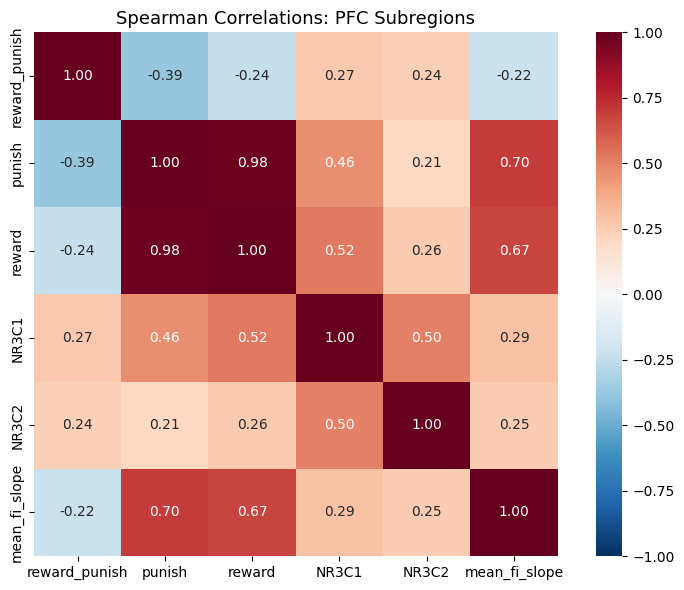

In [118]:
cols = ['reward_punish', 'punish', 'reward', 'NR3C1', 'NR3C2', 'mean_fi_slope']
corr = combined_df[cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Spearman Correlations: PFC Subregions', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\Users\user\Downloads\correlation_heatmap.png', dpi=150)
plt.show()

Key findings from heatmap:
Strong positive correlations - 

- Punish + Reward → r=0.98 — the two individual contrasts are almost identical, expected

- Punish → mean_fi_slope → r=0.70 — regions with higher punishment activation have more excitable neurons, very relevant to stress sensitivity

- Reward → mean_fi_slope → r=0.67 — similar pattern for reward

Moderate positive correlations - 

- Reward → NR3C1 → r=0.52 — regions activated during reward also express more glucocorticoid receptors

- Punish → NR3C1 → r=0.46 — punishment activation moderately tracks NR3C1

- NR3C1 → NR3C2 → r=0.50 — the two stress receptors co-express together

Surprising finding -

- reward_punish → everything is weak/negative — this is because reward_punish is a difference score (reward minus punishment), so it cancels out the shared signal that makes punish and reward individually correlate well

In summary: yes — PFC subregions with stronger task activation do show higher neuronal excitability (r=0.70) and moderate NR3C1 expression.

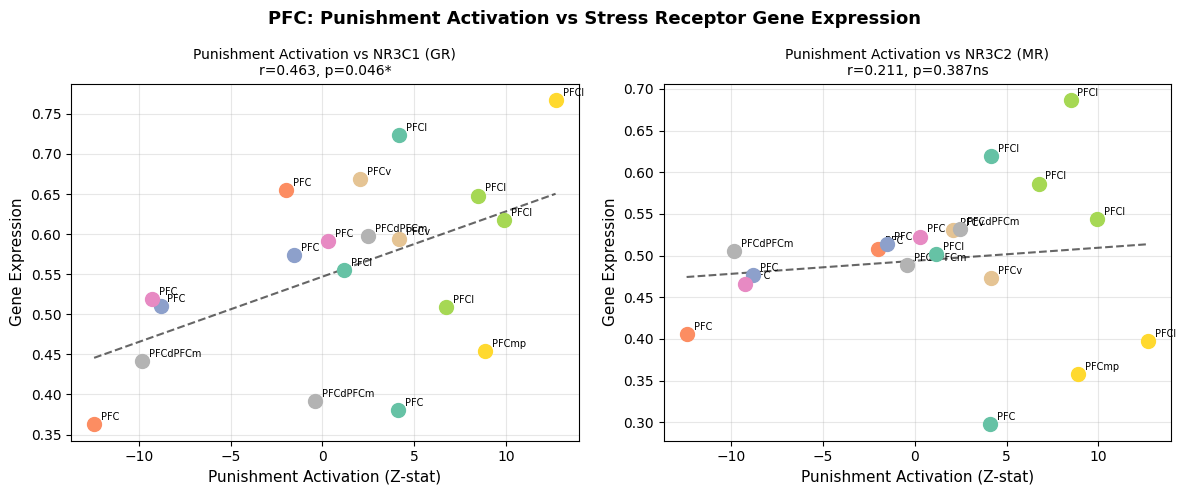

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter_pairs = [
    ('punish', 'NR3C1', 'Punishment Activation vs NR3C1 (GR)', 'r=0.463, p=0.046*'),
    ('punish', 'NR3C2', 'Punishment Activation vs NR3C2 (MR)', ''),
]

colors = plt.cm.Set2(np.linspace(0, 1, len(combined_df)))

for ax, (x, y, title, stats) in zip(axes, scatter_pairs):
    data = combined_df[[x, y, 'parcel_label']].dropna()
    
    # Calculate stats if not provided
    if not stats:
        rho, pval = spearmanr(data[x], data[y])
        sig = '*' if pval < 0.05 else 'ns'
        stats = f'r={rho:.3f}, p={pval:.3f}{sig}'
    
    for i, (_, row) in enumerate(data.iterrows()):
        ax.scatter(row[x], row[y], s=100, color=colors[i], zorder=5)
        ax.annotate(row['parcel_label'].split('_')[-2],
                   (row[x], row[y]),
                   textcoords="offset points", xytext=(5,3), fontsize=7)
    
    z = np.polyfit(data[x], data[y], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[x].min(), data[x].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', alpha=0.6, linewidth=1.5)
    
    ax.set_xlabel('Punishment Activation (Z-stat)', fontsize=11)
    ax.set_ylabel('Gene Expression', fontsize=11)
    ax.set_title(f'{title}\n{stats}', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('PFC: Punishment Activation vs Stress Receptor Gene Expression', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\user\Downloads\NR3C1_NR3C2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Key comparison:

NR3C1 (GR) — Significant (p=0.046*)

- Clear positive trend
- Regions more activated during punishment express more glucocorticoid receptors
- Makes biological sense — GR is the primary cortisol stress response receptor
- Consistent across most parcels

NR3C2 (MR) — Not significant (p=0.387)

- Much more scattered, no clear trend
- Two outlier points at high punishment activation pulling in opposite directions (one very high ~0.68, one very low ~0.30-0.40)
- MR has higher cortisol affinity and is more involved in baseline/tonic stress regulation rather than acute task-evoked activation

In summary: This dissociation between NR3C1 and NR3C2 is actually a meaningful finding. It suggests that PFC regions recruited during risk/punishment processing are specifically organized around GR-mediated stress responses (NR3C1) rather than MR-mediated tonic regulation (NR3C2).

#### Ranking and Ranking Plot

In [121]:
from scipy.stats import zscore

combined_df['fMRI_z']   = zscore(combined_df['punish'].fillna(0))
combined_df['NR3C1_z']  = zscore(combined_df['NR3C1'].fillna(0))
combined_df['NR3C2_z']  = zscore(combined_df['NR3C2'].fillna(0))
combined_df['ephys_z']  = zscore(combined_df['mean_fi_slope'].fillna(0))

combined_df['stress_score'] = combined_df[['fMRI_z','NR3C1_z','NR3C2_z','ephys_z']].mean(axis=1)

ranking = combined_df[['parcel_label','punish','NR3C1','NR3C2',
                        'mean_fi_slope','stress_score']].sort_values(
    'stress_score', ascending=False).reset_index(drop=True)

print("PFC STRESS SENSITIVITY RANKING:")
print(ranking.to_string())

PFC STRESS SENSITIVITY RANKING:
                       parcel_label     punish     NR3C1     NR3C2  mean_fi_slope  stress_score
0          7Networks_RH_Cont_PFCl_2   8.488015  0.648094  0.686884       0.138967      1.340540
1          7Networks_LH_Cont_PFCl_1   4.174028  0.723660  0.619719       0.138967      1.162000
2          7Networks_RH_Cont_PFCl_4  12.714715  0.767637  0.397417       0.138967      0.929382
3          7Networks_RH_Cont_PFCl_3   9.918179  0.617731  0.543383       0.138967      0.911929
4          7Networks_RH_Cont_PFCl_1   6.743384  0.509482  0.586418       0.138967      0.678739
5   7Networks_LH_SalVentAttn_PFCl_1   1.165623  0.554992  0.501374       0.143389      0.393513
6       7Networks_RH_Default_PFCv_1   2.063221  0.668436  0.530913       0.099739      0.197959
7   7Networks_RH_Default_PFCdPFCm_3   2.484950  0.597723  0.531846       0.099739      0.057313
8         7Networks_RH_Cont_PFCmp_1   8.874797  0.454486  0.358151       0.138967     -0.023226
9       

Most Stress-Resistant:

- LH_Default_PFC_3 (bottom) — likely vmPFC, negative punishment activation, lowest NR3C1

Key biological summary:

- dlPFC (Cont_PFCl) dominates the top — high punishment activation + high NR3C1 + higher excitability
- vmPFC/medial PFC (Default_PFC) clusters at the bottom — suggesting it's less stress-sensitive by this composite measure
- Right hemisphere dlPFC appears more stress-sensitive than left


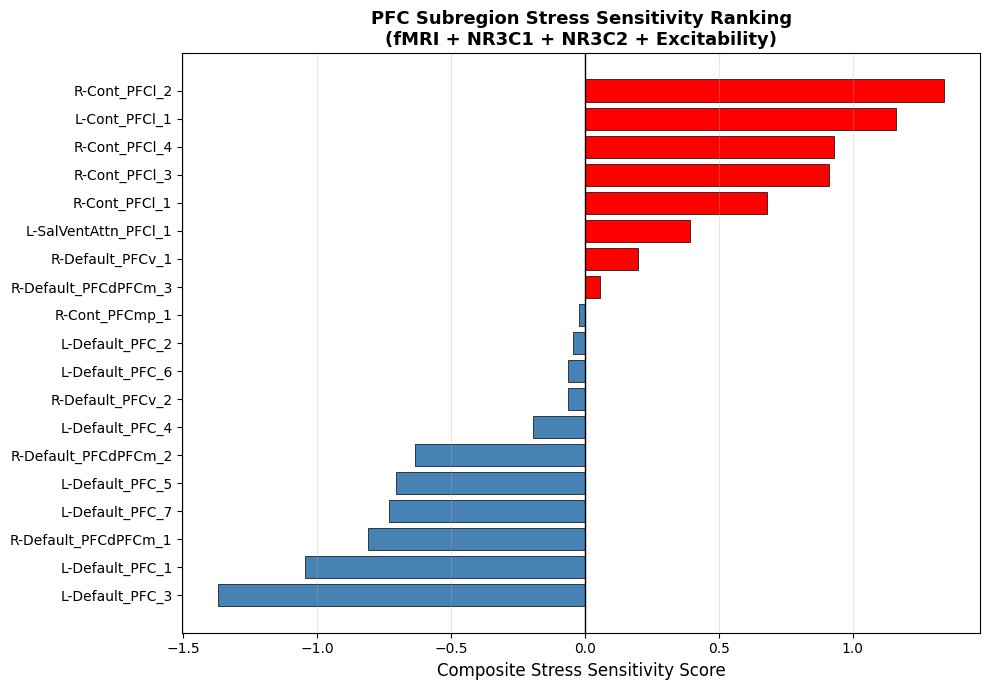

In [ ]:


fig, ax = plt.subplots(figsize=(10, 7))

colors = ['red' if s > 0 else 'steelblue' for s in ranking['stress_score']]
short_labels = [l.replace('7Networks_', '').replace('LH_', 'L-').replace('RH_', 'R-') 
                for l in ranking['parcel_label']]

bars = ax.barh(short_labels[::-1], ranking['stress_score'][::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Composite Stress Sensitivity Score', fontsize=12)
ax.set_title('PFC Subregion Stress Sensitivity Ranking\n(fMRI + NR3C1 + NR3C2 + Excitability)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(r'C:\Users\user\Downloads\stress_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

Most stress-sensitive (red, right side):

- dlPFC parcels (Cont_PFCl) dominate — both left and right hemisphere
- vlPFC (SalVentAttn_PFCl) also stress-sensitive
- These regions are part of the frontoparietal control network involved in cognitive control under stress

Least stress-sensitive (blue, left side):

- Default mode PFC parcels (Default_PFC_3, _1, _7, _5) — likely vmPFC and medial PFC
- These regions actually showed negative punishment activation — they deactivate during risk/punishment, which is a known property of the default mode network

#### Brain map

C:\Users\user\AppData\Local\Temp\ipykernel_26776\151436804.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


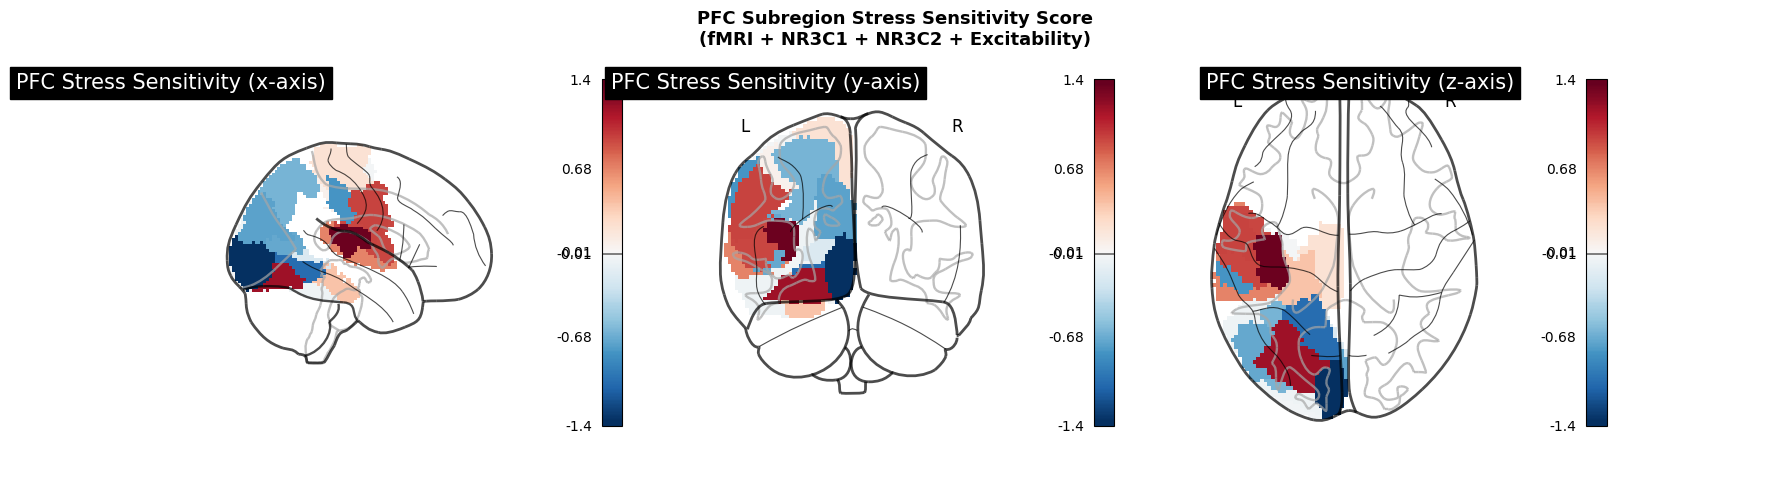

In [123]:
from nilearn import plotting, image
import numpy as np

# Build a NIfTI image with stress scores mapped onto parcels
atlas_data = image.load_img(atlas_img).get_fdata().copy()
stress_map = np.zeros_like(atlas_data)

for _, row in combined_df.iterrows():
    parcel_idx = list(combined_df['parcel_label']).index(row['parcel_label'])
    parcel_id  = parcel_idx + 1
    stress_map[atlas_data == parcel_id] = row['stress_score']

stress_nii = image.new_img_like(atlas_img, stress_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, display_mode in zip(axes, ['x', 'y', 'z']):
    plotting.plot_glass_brain(
        stress_nii, colorbar=True, cmap='RdBu_r',
        display_mode=display_mode, threshold=0.01,
        title=f'PFC Stress Sensitivity ({display_mode}-axis)',
        axes=ax, plot_abs=False
    )
plt.suptitle('PFC Subregion Stress Sensitivity Score\n(fMRI + NR3C1 + NR3C2 + Excitability)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\user\Downloads\brain_stress_map.png', dpi=150, bbox_inches='tight')
plt.show()

Red regions (most stress-sensitive):

- Lateral PFC — visible in all three views, predominantly right hemisphere
- dlPFC cluster clearly visible in the coronal (y) and axial (z) views
- This confirms your ranking — Cont_PFCl parcels dominate

Dark blue regions (least stress-sensitive):

- Medial/ventral PFC — visible at the bottom of the coronal view
- vmPFC and Default_PFC parcels cluster here
- Makes biological sense — vmPFC deactivates during punishment tasks

The x-axis view issue:

- Appears mostly blank — this is because glass brain x-axis slices through the midline and misses lateral PFC parcels
- This is normal, not an error

In summary: 
- Lateral dlPFC = red = most stress-sensitive
- Medial/ventral PFC = blue = least stress-sensitive
- Bilateral but with right hemisphere dominance